Downloading Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("adlteam/kaist-dataset")

print("Path to dataset files:", path)

100%|██████████| 18.1G/18.1G [03:23<00:00, 95.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adlteam/kaist-dataset/versions/1


In [ ]:
import os

print("Contents of dataset:")
print(os.listdir(path))

Contents of dataset:
['set02', 'set04', 'set05', 'set03', 'set00', 'set01']


In [ ]:
sets = sorted(os.listdir(path))
print("Available Sets:", sets)

set00_path = os.path.join(path, "set00")
print("\nExample Files in Set 00:")
print(os.listdir(set00_path))

Available Sets: ['set00', 'set01', 'set02', 'set03', 'set04', 'set05']

Example Files in Set 00:
['V006', 'V003', 'V008', 'V001', 'V004', 'V005', 'V007', 'V002', 'V000']


In [ ]:
import shutil
organized_path = "/content/kaist_organized"
os.makedirs(os.path.join(organized_path, "visible"), exist_ok=True)
os.makedirs(os.path.join(organized_path, "lwir"), exist_ok=True)

def extract_images():
    for set_name in sorted(os.listdir(path)):
        set_path = os.path.join(path, set_name)
        for video in sorted(os.listdir(set_path)):
            video_path = os.path.join(set_path, video)
            visible_path = os.path.join(video_path, "visible")
            lwir_path = os.path.join(video_path, "lwir")

            if os.path.exists(visible_path) and os.path.exists(lwir_path):
                for img in sorted(os.listdir(visible_path)):
                    shutil.copy(os.path.join(visible_path, img),
                                os.path.join(organized_path, "visible", f"{set_name}_{video}_{img}"))
                for img in sorted(os.listdir(lwir_path)):
                    shutil.copy(os.path.join(lwir_path, img),
                                os.path.join(organized_path, "lwir", f"{set_name}_{video}_{img}"))
extract_images()

Train/Val Split

In [ ]:
import random
from sklearn.model_selection import train_test_split

visible_dir = os.path.join(organized_path, "visible")
lwir_dir = os.path.join(organized_path, "lwir")
all_rgb_files = sorted(os.listdir(visible_dir))

day_rgb = [f for f in all_rgb_files if "set00" in f or "set01" in f or "set02" in f]
night_rgb = [f for f in all_rgb_files if "set03" in f or "set04" in f or "set05" in f]

day_rgb = random.sample(day_rgb, 3000)
night_rgb = random.sample(night_rgb, 7000)
selected_rgb = day_rgb + night_rgb

train_files, val_files = train_test_split(selected_rgb, test_size=0.2, random_state=42)

all_rgb_files = sorted(os.listdir(visible_dir))

used_files = set(selected_rgb)
leftover_files = [f for f in all_rgb_files if f not in used_files]

test_files = random.sample(leftover_files, 2000)

print(f"Train split: {len(train_files)} files")
print(f"Val split: {len(val_files)} files (mixed)")

Train split: 8000 files
Val split: 2000 files (mixed)


Preprocessing

In [ ]:
import cv2
import numpy as np
import torch
from tqdm import tqdm
import gc

#Calculating statistics of the dataset to use them for normalization
def calculate_stats(sample_list):
    rgb_means, rgb_stds, ir_means, ir_stds = [], [], [], []

    for f in tqdm(sample_list[:500], desc="Calculating stats"):
        rgb = cv2.imread(os.path.join(visible_dir, f))
        ir = cv2.imread(os.path.join(lwir_dir, f), cv2.IMREAD_GRAYSCALE)
        if rgb is not None and ir is not None:
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB) / 255.0
            ir = ir / 255.0
            rgb_means.append(rgb.mean(axis=(0, 1)))
            rgb_stds.append(rgb.std(axis=(0, 1)))
            ir_means.append(ir.mean())
            ir_stds.append(ir.std())
    return np.mean(rgb_means, axis=0), np.mean(rgb_stds, axis=0), np.mean(ir_means), np.mean(ir_stds)

RGB_MEAN, RGB_STD, IR_MEAN, IR_STD = calculate_stats(selected_rgb)

IMG_SIZE = 256

def process_and_save(files, split_type):
    os.makedirs(f"/content/Processed/{split_type}", exist_ok=True)
    for f in tqdm(files, desc=f"Processing {split_type}"):
        try:
            rgb = cv2.imread(os.path.join(visible_dir, f))
            ir = cv2.imread(os.path.join(lwir_dir, f), cv2.IMREAD_GRAYSCALE)

            if rgb is None or ir is None:
                continue

            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
            #Normalization
            rgb = (rgb.astype(np.float32) / 255.0 - RGB_MEAN) / RGB_STD
            ir = cv2.resize(ir, (IMG_SIZE, IMG_SIZE))
            ir = (ir.astype(np.float32) / 255.0 - IR_MEAN) / IR_STD

            rgb_tensor = torch.from_numpy(rgb).permute(2, 0, 1)
            ir_tensor = torch.from_numpy(ir).unsqueeze(0)
            #saving as .pt
            torch.save({
                'rgb': rgb_tensor,
                'ir': ir_tensor,
                'filename': f,
                'mean_std': (RGB_MEAN, RGB_STD, IR_MEAN, IR_STD)
            }, f"/content/Processed/{split_type}/{os.path.splitext(f)[0]}.pt")
        except Exception as e:
            print(f"Skipping {f}: {e}")
        gc.collect()

process_and_save(train_files, "train")
process_and_save(val_files, "validation")
process_and_save(test_files, "test")

Processing test: 100%|██████████| 2000/2000 [05:25<00:00,  6.14it/s]


Visualizing Processed Images

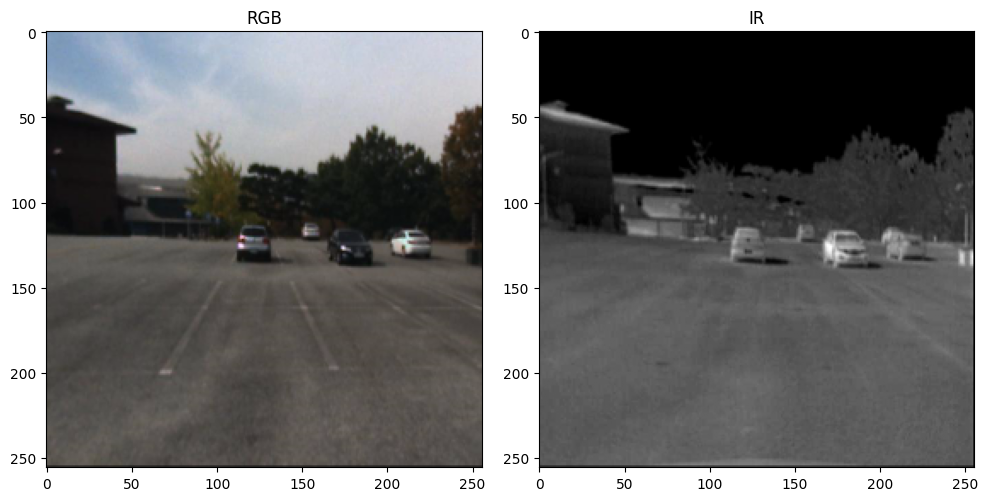

In [ ]:
import matplotlib.pyplot as plt
import os
import torch

output_dir = "/content/Processed/train"

sample_path = os.path.join(output_dir, sorted(os.listdir(output_dir))[0])
data = torch.load(sample_path, weights_only=False)

def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    return tensor * std + mean

rgb = denormalize(data['rgb'], data['mean_std'][0], data['mean_std'][1])
ir = denormalize(data['ir'], data['mean_std'][2], data['mean_std'][3])

# Clamp to [0, 1]
rgb = rgb.clamp(0, 1)
ir = ir.clamp(0, 1)

# Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb.permute(1, 2, 0).cpu().numpy())
plt.title("RGB")

plt.subplot(1, 2, 2)
plt.imshow(ir.squeeze().cpu().numpy(), cmap='gray')
plt.title("IR")

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
from torch.utils.data import Dataset

class KAISTFusionDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.samples = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.samples[idx])
        data = torch.load(path, weights_only=False)

        rgb = data['rgb'].float()
        ir = data['ir'].float()

        return rgb, ir

In [ ]:
import os
from torch.utils.data import DataLoader

train_dataset = KAISTFusionDataset("/content/Processed/train")
val_dataset = KAISTFusionDataset("/content/Processed/test")

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

The Fusion Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # RGB stream encoder
        self.rgb_enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        self.rgb_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        # IR stream encoder
        self.ir_enc1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        self.ir_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        # Dual-path attention fusion
        self.ir_attention = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid()
        )
        self.rgb_attention = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid()
        )

        # Dynamic feature modulation
        self.ir_modulation = nn.Sequential(
            nn.Conv2d(128, 128, 1),
            nn.Tanh()
        )

        # Decoder with skip connections
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2)
        )
        self.dec1_skip = nn.Conv2d(128, 128, 1)

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2)
        )

        self.dec3 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Tanh()
        )

        self.tone_adjust = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, rgb, ir):
        rgb_feat1 = self.rgb_enc1(rgb)
        rgb_feat2 = self.rgb_enc2(rgb_feat1)

        ir_feat1 = self.ir_enc1(ir)
        ir_feat2 = self.ir_enc2(ir_feat1)

        ir_attn = self.ir_attention(ir_feat2)
        rgb_attn = self.rgb_attention(rgb_feat2)
        ir_mod = self.ir_modulation(ir_feat2)

        fused = (rgb_feat2 * rgb_attn) + (ir_feat2 * (1 + ir_attn - rgb_attn)) * ir_mod

        d1 = self.dec1(fused)
        skip = self.dec1_skip(torch.cat([rgb_feat1, ir_feat1], dim=1))
        d1 = torch.cat([d1, skip], dim=1)

        d2 = self.dec2(d1)
        output = self.dec3(d2)
        output = self.tone_adjust(output)

        return output.clamp(-1, 1)

The Fusion Loss

In [ ]:
from torchvision.models import vgg16, VGG16_Weights
import torch.nn.functional as F
import torch
import torch.nn as nn
from pytorch_msssim import SSIM

class FusionLoss(nn.Module):
    def __init__(self, device='cuda'):
        super().__init__()
        self.device = device

        # Core losses
        self.l1_loss = nn.L1Loss()
        self.ssim = SSIM(data_range=1.0, channel=3, size_average=True).to(device)

        # Perceptual network (VGG16 up to relu2_2)
        self.vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features[:9].eval().to(device)
        for param in self.vgg.parameters():
            param.requires_grad = False

        # Normalization
        self.register_buffer('vgg_mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('vgg_std', torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        # Gradient computation
        self.register_buffer('sobel_x', torch.tensor([[[1, 0, -1], [2, 0, -2], [1, 0, -1]]],
                           dtype=torch.float32).view(1,1,3,3))
        self.register_buffer('sobel_y', torch.tensor([[[1, 2, 1], [0, 0, 0], [-1, -2, -1]]],
                           dtype=torch.float32).view(1,1,3,3))

        # Adaptive parameters
        self.base_dark_threshold = 0.25
        self.register_parameter('grad_weight', nn.Parameter(torch.tensor(0.35)))
        self.register_parameter('rgb_weight', nn.Parameter(torch.tensor(0.5)))

    def compute_gradients(self, x, target_size=None):
        """Computing gradient magnitude with optional resizing"""
        if x.shape[1] == 3:
            x = x.mean(dim=1, keepdim=True)
        grad_x = F.conv2d(x, self.sobel_x, padding=1)
        grad_y = F.conv2d(x, self.sobel_y, padding=1)
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-6)
        if target_size is not None:
            grad_mag = F.interpolate(grad_mag, size=target_size, mode='bilinear')
        return grad_mag

    def forward(self, fused, rgb, ir):
        fused_01 = (fused + 1.0) / 2.0
        rgb_01 = (rgb + 1.0) / 2.0
        ir_01 = (ir + 1.0) / 2.0

        """ 1. RGB Reconstruction """
        brightness = rgb_01.mean(dim=1, keepdim=True)
        img_mean = brightness.mean()

        dark_threshold = max(0.15, min(0.3, self.base_dark_threshold * (img_mean + 0.5)))
        bright_threshold = min(0.55, max(0.4, 0.4 + img_mean * 0.5))

        dark_mask = (brightness < dark_threshold).float()
        bright_mask = (brightness > bright_threshold).float()
        mid_mask = 1.0 - dark_mask - bright_mask

        rgb_reconstruction = F.l1_loss(fused, rgb, reduction='none')

        rgb_weights = (0.1 * dark_mask +
                      0.7 * bright_mask +
                      0.3 * mid_mask)
        loss_rgb = (rgb_reconstruction * rgb_weights).mean()

        """ 2. IR Gradient Preservation  """
        grad_fused = self.compute_gradients(fused)
        grad_ir = self.compute_gradients(ir)

        grad_loss = F.l1_loss(grad_fused, grad_ir, reduction='none')

        grad_fused_half = self.compute_gradients(F.avg_pool2d(fused, 2),
                                               target_size=grad_fused.shape[2:])
        grad_ir_half = self.compute_gradients(F.avg_pool2d(ir, 2),
                                            target_size=grad_ir.shape[2:])
        grad_loss += 0.5 * F.l1_loss(grad_fused_half, grad_ir_half, reduction='none')

        grad_weights = (1.0 + 2.0 * dark_mask) * (1.0 - 0.5 * bright_mask)
        loss_grad = (grad_loss * grad_weights).mean()

        """ 3. IR Feature Preservation  """
        ir_feature_loss = torch.tensor(0.0, device=self.device)
        if dark_mask.sum() > 0:
            chunk_size = 512*512
            fused_green = fused[:,1:2] if fused.shape[1] > 1 else fused
            idx = dark_mask.bool()

            for i in range(0, idx.sum(), chunk_size):
                chunk_idx = idx.nonzero()[i:i+chunk_size]
                fused_chunk = fused_green[chunk_idx[:,0], :, chunk_idx[:,1], chunk_idx[:,2]]
                ir_chunk = ir[chunk_idx[:,0], :, chunk_idx[:,1], chunk_idx[:,2]]
                chunk_loss = 1.0 - torch.cosine_similarity(fused_chunk, ir_chunk, dim=1).mean()
                ir_feature_loss += chunk_loss * (len(chunk_idx) / idx.sum())

        """ 6. Perceptual & Structural Losses """
        def resize(x):
            return F.interpolate(x, size=224, mode='bilinear')

        def normalize(x):
            return (x - self.vgg_mean) / self.vgg_std

        with torch.no_grad():
            vgg_input = self.vgg(normalize(resize(fused_01)))
            vgg_target = self.vgg(normalize(resize(rgb_01)))
            vgg_input = vgg_input / (vgg_input.norm(dim=1, keepdim=True) + 1e-6)
            vgg_target = vgg_target / (vgg_target.norm(dim=1, keepdim=True) + 1e-6)

        loss_perceptual = self.l1_loss(vgg_input, vgg_target)
        loss_ssim = 1 - self.ssim(fused_01, rgb_01)

        """ 7. Artifact Suppression """
        checker_loss = F.l1_loss(fused[..., ::2, ::2], fused[..., 1::2, 1::2])
        color_loss = F.l1_loss(fused[:,0]-fused[:,1], rgb[:,0]-rgb[:,1])

        """ Composite Loss """
        total_loss = (
            self.rgb_weight * loss_rgb +
            self.grad_weight * loss_grad +
            0.1 * ir_feature_loss +
            0.05 * loss_perceptual +
            0.05 * loss_ssim +
            0.02 * checker_loss +
            0.03 * color_loss
        )

        return {
            'total': total_loss,
            'rgb': loss_rgb,
            'grad': loss_grad,
            'ir_feature': ir_feature_loss,
            'percep': loss_perceptual,
            'ssim': loss_ssim,
            'artifacts': checker_loss + color_loss,
            'dark_ratio': dark_mask.mean(),
            'bright_ratio': bright_mask.mean(),
            'adaptive_dark_thresh': dark_threshold,
            'adaptive_bright_thresh': bright_threshold
        }

    def update_threshold(self, decay=0.98):
        """Gradually focus on darker regions"""
        self.base_dark_threshold *= decay
        self.base_dark_threshold = max(self.base_dark_threshold, 0.15)

In [ ]:
def train_fusion(model, train_loader, val_loader, epochs=50, lr=1e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = FusionLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'dark_ratio': []}

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        epoch_dark_ratio = 0.0

        for rgb, ir in train_loader:
            rgb, ir = rgb.float().to(device), ir.float().to(device)

            optimizer.zero_grad()
            fused = model(rgb, ir)
            loss_dict = criterion(fused, rgb, ir)

            loss_dict['total'].backward()
            optimizer.step()

            epoch_train_loss += loss_dict['total'].item()
            epoch_dark_ratio += loss_dict['dark_ratio'].item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for rgb, ir in val_loader:
                rgb, ir = rgb.float().to(device), ir.float().to(device)
                fused = model(rgb, ir)
                loss_dict = criterion(fused, rgb, ir)
                val_loss += loss_dict['total'].item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_dark_ratio = epoch_dark_ratio / len(train_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['dark_ratio'].append(avg_dark_ratio)

        # Update LR and save best model
        scheduler.step(avg_val_loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_fusion_model.pth")

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} ")

    return history

In [ ]:
model = FusionModel()

history = train_fusion(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=15,
    lr=1e-4
)

Epoch 1/15 | Train Loss: 0.4957 | Val Loss: 0.5251 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 2/15 | Train Loss: 0.3613 | Val Loss: 0.4984 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 3/15 | Train Loss: 0.3501 | Val Loss: 0.4882 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 4/15 | Train Loss: 0.3440 | Val Loss: 0.4817 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 5/15 | Train Loss: 0.3384 | Val Loss: 0.4769 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 6/15 | Train Loss: 0.3355 | Val Loss: 0.4718 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 7/15 | Train Loss: 0.3321 | Val Loss: 0.4716 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 8/15 | Train Loss: 0.3298 | Val Loss: 0.4651 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 9/15 | Train Loss: 0.3281 | Val Loss: 0.4638 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 10/15 | Train Loss: 0.3267 | Val Loss: 0.4610 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 11/15 | Train Loss: 0.3247 | Val Loss: 0.4608 | Dark Ratio: 0.44 | LR: 1.00e-04
Epoch 12/15 | Train Loss: 0.3235 | Val Loss: 0.4572 | Dark Rati

ValueError: too many values to unpack (expected 2)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/fusion_model.pth "/content/drive/MyDrive"

!ls -lh "/content/drive/MyDrive/fusion_model.pth"

Mounted at /content/drive
-rw------- 1 root root 3.9M Apr  1 02:01 /content/drive/MyDrive/fusion_model.pth


Visualizing Fused Images

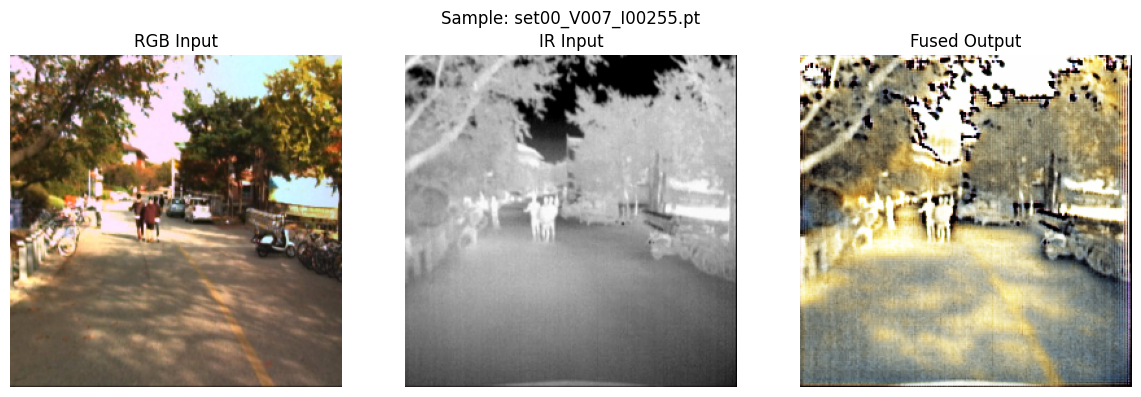

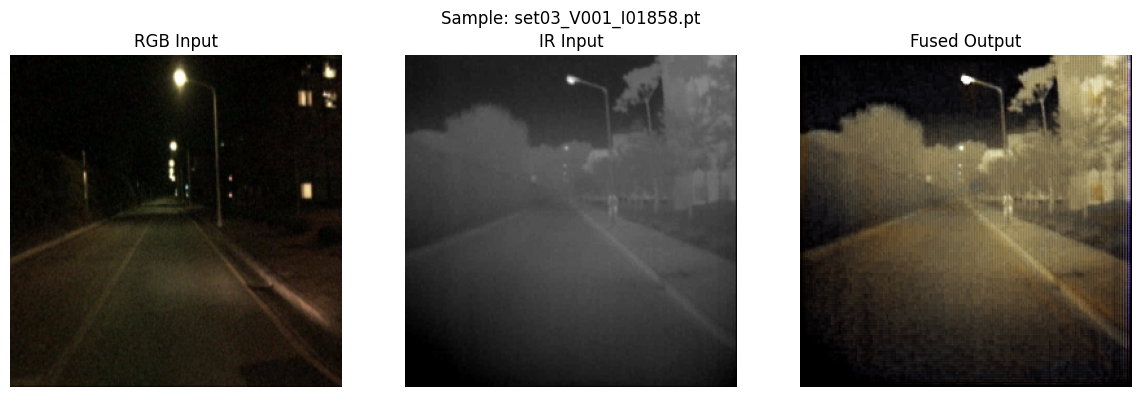

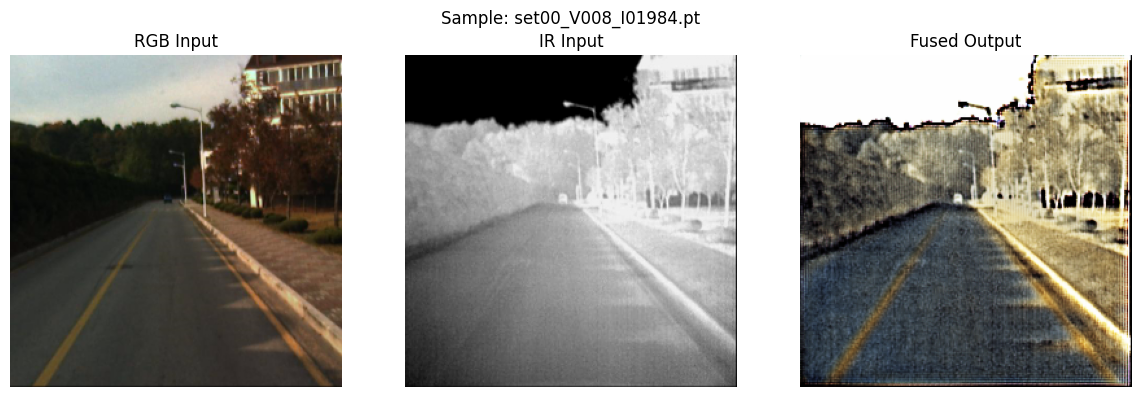

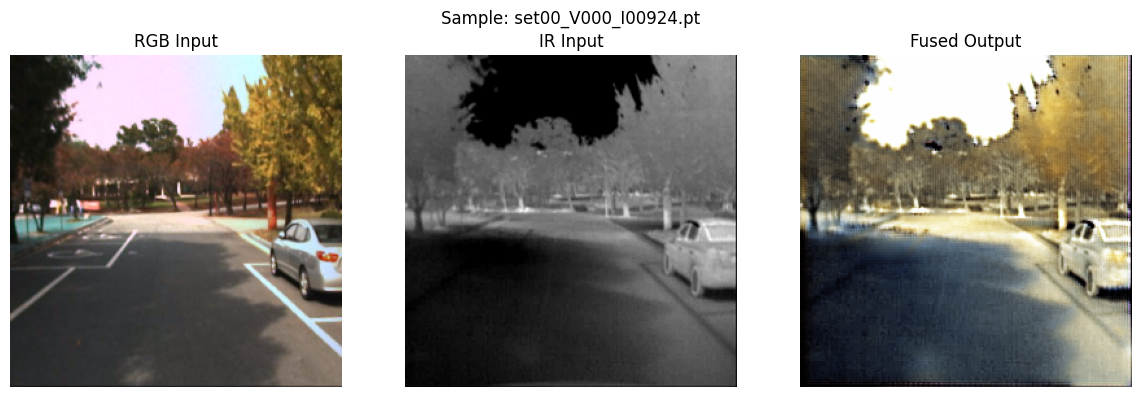

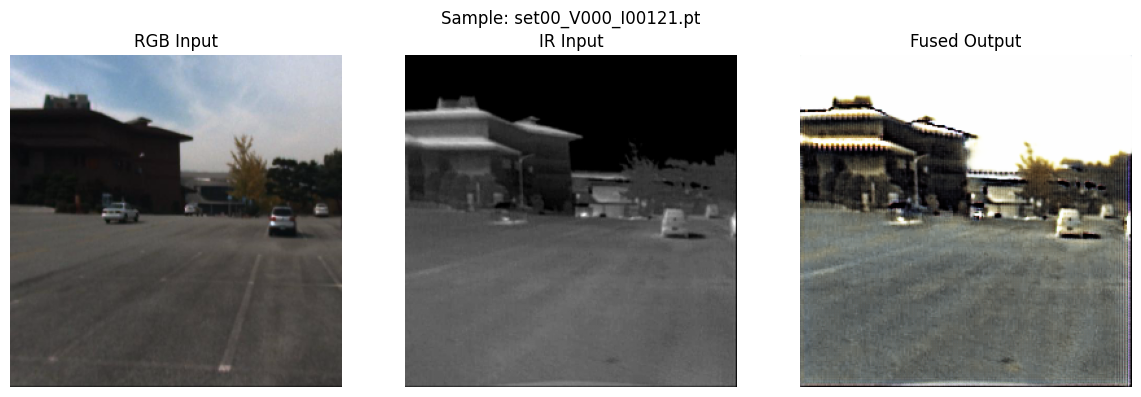

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

test_dir = "/content/Processed/test"
model_path = "fusion_model.pth"

#Loading Model
model = FusionModel().cuda()
model.load_state_dict(torch.load(model_path))
model.eval()


sample_files = random.sample(os.listdir(test_dir), 5)  # visualize 5 random samples

def denormalize(tensor, mean, std):
    return tensor * torch.tensor(std).view(-1, 1, 1) + torch.tensor(mean).view(-1, 1, 1)

model.eval()
model.cuda()

for file in sample_files:
    data = torch.load(os.path.join(test_dir, file), weights_only=False)

    rgb = data['rgb'].unsqueeze(0).cuda().float()
    ir = data['ir'].unsqueeze(0).cuda().float()
    with torch.no_grad():
        fused = model(rgb, ir)

    rgb = denormalize(data['rgb'], data['mean_std'][0], data['mean_std'][1])
    ir = denormalize(data['ir'], data['mean_std'][2], data['mean_std'][3])
    fused = fused.squeeze(0).cpu()
    fused_vis = (fused + 1.0) / 2.0  # from [-1, 1] to [0, 1]

    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(rgb.permute(1, 2, 0).numpy())
    plt.title("RGB Input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(ir.squeeze().cpu().numpy(), cmap='gray')
    plt.title("IR Input")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(fused_vis.permute(1, 2, 0).numpy())
    plt.title("Fused Output")
    plt.axis("off")

    plt.suptitle(f"Sample: {file}")
    plt.tight_layout()
    plt.show()



In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm
import cv2
import torch.nn.functional as F
import gc

#Gradient magnitude
def compute_gradient_magnitude(img):
    if isinstance(img, torch.Tensor):
        img = img.squeeze().cpu().numpy()
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(grad_x**2 + grad_y**2)

#Mutual Information
def mutual_information(hgram):
    pxy = hgram / float(np.sum(hgram))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

#Load model
model = FusionModel().cuda().eval()
model.load_state_dict(torch.load("fusion_model.pth"))
print("Model loaded.")

#Evaluation
test_dir = "/content/Processed/test"
test_files = sorted([f for f in os.listdir(test_dir) if f.endswith(".pt")])
random_subset = test_files[:30]

ssim_scores, psnr_scores = [], []
grad_preservation_scores, mi_scores = [], []

for file in tqdm(random_subset, desc="Evaluating"):
    sample = torch.load(os.path.join(test_dir, file), map_location='cpu', weights_only= False)
    rgb = sample['rgb'].unsqueeze(0).float().cuda()
    ir = sample['ir'].unsqueeze(0).float().cuda()
    with torch.no_grad():
        fused = model(rgb, ir)

    # Convert to numpy
    fused_np = fused.squeeze().cpu().clamp(-1, 1).numpy()
    rgb_np = rgb.squeeze().cpu().numpy()
    ir_np = ir.squeeze().cpu().numpy()

    fused_img = ((fused_np + 1.0) / 2.0).transpose(1, 2, 0)
    rgb_img = ((rgb_np + 1.0) / 2.0).transpose(1, 2, 0)
    ir_img = ((ir_np + 1.0) / 2.0).squeeze()

    # SSIM and PSNR
    ssim_score = ssim(rgb_img, fused_img, channel_axis=2, data_range=1.0)
    psnr_score = psnr(rgb_img, fused_img, data_range=1.0)
    ssim_scores.append(ssim_score)
    psnr_scores.append(psnr_score)

    # Gradient preservation
    grad_ir = compute_gradient_magnitude(ir_img)
    grad_fused = compute_gradient_magnitude(fused_img.mean(axis=2))
    grad_pres = 1.0 - np.mean(np.abs(grad_ir - grad_fused))
    grad_preservation_scores.append(grad_pres)

    # Mutual Information (IR ↔ Fused)
    hgram, _, _ = np.histogram2d(ir_img.ravel(), fused_img.mean(axis=2).ravel(), bins=64)
    mi = mutual_information(hgram)
    mi_scores.append(mi)

    del rgb, ir, fused
    gc.collect()

# Results
print("=== Quantitative Fusion Evaluation ===")
print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
print(f"Average IR Gradient Preservation: {np.mean(grad_preservation_scores):.4f}")
print(f"Average Mutual Information (IR ↔ Fused): {np.mean(mi_scores):.4f}")

Model loaded.


Evaluating: 100%|██████████| 30/30 [00:06<00:00,  4.51it/s]

=== Quantitative Fusion Evaluation ===
Average SSIM: 0.3250
Average PSNR: 10.99 dB
Average IR Gradient Preservation: 0.9433
Average Mutual Information (IR ↔ Fused): 0.9749
